In [ ]:
!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn joblib -q

In [ ]:
from google.colab import files
uploaded = files.upload()  # chọn file head_to_head.json

Saving head_to_head.json to head_to_head (1).json


In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
with open('head_to_head.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Tổng số trận: {len(df)}')
print(f'Thời gian: {df.date.min().date()} → {df.date.max().date()}')
print(f'Số cặp đội: {df.groupby(["home_team_id","away_team_id"]).ngroups}')
print(f'Các giải đấu: {df.league_name.unique()}')
df.head()

Tổng số trận: 4325
Thời gian: 2010-08-14 → 2026-08-12
Số cặp đội: 380
Các giải đấu: ['Premier League' 'Championship' 'League Cup' 'EFL Trophy' 'League One'
 'FA Cup' 'Community Shield' 'UEFA Europa League'
 'International Champions Cup' 'UEFA Champions League'
 'Premier League Asia Trophy' 'UEFA Super Cup' 'Friendlies Clubs'
 'Premier League - Summer Series']


,id,home_team_id,home_team_name,away_team_id,away_team_name,league_name,home_goals,away_goals,date
0,1224,47,Tottenham,50,Manchester City,Premier League,0.0,0.0,2010-08-14
1,4015,66,Aston Villa,48,West Ham,Premier League,3.0,0.0,2010-08-14
2,637,40,Liverpool,42,Arsenal,Premier League,1.0,1.0,2010-08-15
3,1564,33,Manchester United,34,Newcastle,Premier League,3.0,0.0,2010-08-16
4,95,45,Everton,39,Wolves,Premier League,1.0,1.0,2010-08-21


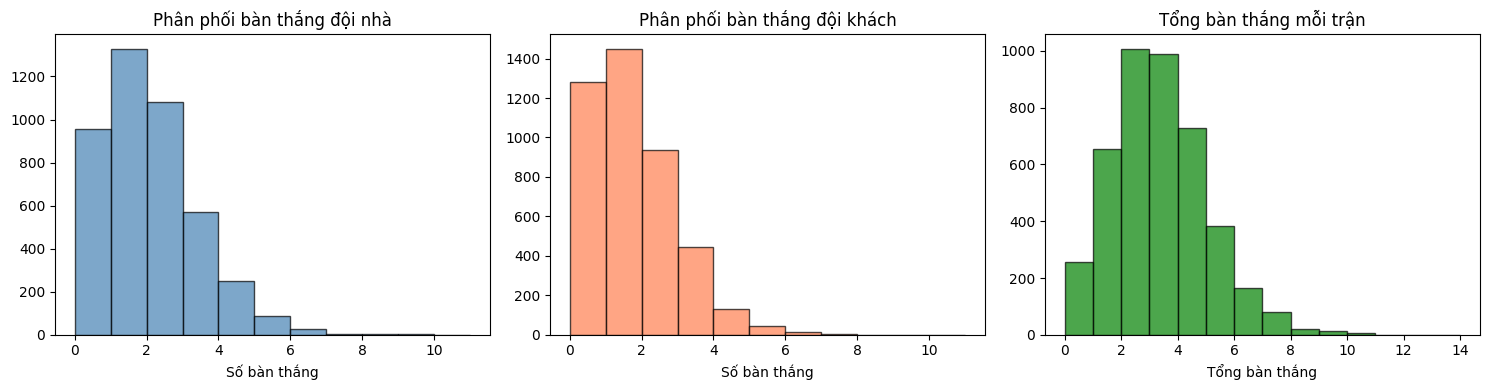

Trung bình bàn thắng đội nhà: 1.593
Trung bình bàn thắng đội khách: 1.278


In [ ]:
# Phân tích phân phối bàn thắng
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['home_goals'], bins=range(0, 12), edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_title('Phân phối bàn thắng đội nhà')
axes[0].set_xlabel('Số bàn thắng')

axes[1].hist(df['away_goals'], bins=range(0, 12), edgecolor='black', color='coral', alpha=0.7)
axes[1].set_title('Phân phối bàn thắng đội khách')
axes[1].set_xlabel('Số bàn thắng')

total_goals = df['home_goals'] + df['away_goals']
axes[2].hist(total_goals, bins=range(0, 15), edgecolor='black', color='green', alpha=0.7)
axes[2].set_title('Tổng bàn thắng mỗi trận')
axes[2].set_xlabel('Tổng bàn thắng')

plt.tight_layout()
plt.savefig('goals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Trung bình bàn thắng đội nhà: {df['home_goals'].mean():.3f}")
print(f"Trung bình bàn thắng đội khách: {df['away_goals'].mean():.3f}")

In [ ]:
def compute_decay_weight(dates, reference_date, half_life_days=365):
    """Trọng số giảm dần theo thời gian (trận gần đây quan trọng hơn)"""
    days_diff = (reference_date - dates).dt.days
    return np.exp(-np.log(2) * days_diff / half_life_days)


def extract_h2h_features(df, idx, n_recent=10, half_life_days=365):
    """
    Tính feature cho trận đấu tại index idx.
    Chỉ dùng dữ liệu TRƯỚC trận đó để tránh data leakage.
    """
    row = df.iloc[idx]
    home_id = row['home_team_id']
    away_id = row['away_team_id']
    match_date = row['date']
    league = row['league_name']

    # Lấy lịch sử đối đầu (cả hai chiều)
    h2h_mask = (
        ((df['home_team_id'] == home_id) & (df['away_team_id'] == away_id)) |
        ((df['home_team_id'] == away_id) & (df['away_team_id'] == home_id))
    ) & (df['date'] < match_date)
    h2h = df[h2h_mask].copy().tail(n_recent)

    # Lịch sử đội nhà (tất cả trận)
    home_all = df[((df['home_team_id'] == home_id) | (df['away_team_id'] == home_id)) &
                  (df['date'] < match_date)].copy().tail(n_recent * 2)

    # Lịch sử đội khách (tất cả trận)
    away_all = df[((df['home_team_id'] == away_id) | (df['away_team_id'] == away_id)) &
                  (df['date'] < match_date)].copy().tail(n_recent * 2)

    # Lịch sử đội nhà chơi sân nhà
    home_home = df[(df['home_team_id'] == home_id) &
                   (df['date'] < match_date)].copy().tail(n_recent)

    # Lịch sử đội khách chơi sân khách
    away_away = df[(df['away_team_id'] == away_id) &
                   (df['date'] < match_date)].copy().tail(n_recent)

    feat = {}

    # ── H2H features ──────────────────────────────────────────
    if len(h2h) > 0:
        weights = compute_decay_weight(h2h['date'], match_date, half_life_days)
        weights = weights / weights.sum()

        # Góc nhìn từ đội nhà
        home_goals_h2h = np.where(h2h['home_team_id'] == home_id,
                                   h2h['home_goals'], h2h['away_goals'])
        away_goals_h2h = np.where(h2h['home_team_id'] == home_id,
                                   h2h['away_goals'], h2h['home_goals'])

        feat['h2h_home_goals_wavg'] = np.dot(weights, home_goals_h2h)
        feat['h2h_away_goals_wavg'] = np.dot(weights, away_goals_h2h)
        feat['h2h_goal_diff_wavg']  = feat['h2h_home_goals_wavg'] - feat['h2h_away_goals_wavg']
        feat['h2h_home_goals_avg']  = home_goals_h2h.mean()
        feat['h2h_away_goals_avg']  = away_goals_h2h.mean()
        feat['h2h_n_matches']       = len(h2h)

        # Tỷ lệ thắng/hòa/thua
        results = np.sign(home_goals_h2h - away_goals_h2h)
        feat['h2h_win_rate']   = (results == 1).mean()
        feat['h2h_draw_rate']  = (results == 0).mean()
        feat['h2h_loss_rate']  = (results == -1).mean()

        # Trọng số thắng/thua (có decay)
        feat['h2h_win_rate_w']  = float(np.dot(weights, results == 1))
        feat['h2h_loss_rate_w'] = float(np.dot(weights, results == -1))

        # Số bàn trung bình (đơn giản)
        feat['h2h_total_goals_avg'] = (home_goals_h2h + away_goals_h2h).mean()

        # Phong độ 3 trận gần nhất
        last3_home = home_goals_h2h[-3:]
        last3_away = away_goals_h2h[-3:]
        feat['h2h_home_goals_last3'] = last3_home.mean() if len(last3_home) else feat['h2h_home_goals_avg']
        feat['h2h_away_goals_last3'] = last3_away.mean() if len(last3_away) else feat['h2h_away_goals_avg']
    else:
        # Không có lịch sử H2H → điền giá trị global
        for k in ['h2h_home_goals_wavg','h2h_away_goals_wavg','h2h_goal_diff_wavg',
                   'h2h_home_goals_avg','h2h_away_goals_avg','h2h_n_matches',
                   'h2h_win_rate','h2h_draw_rate','h2h_loss_rate',
                   'h2h_win_rate_w','h2h_loss_rate_w','h2h_total_goals_avg',
                   'h2h_home_goals_last3','h2h_away_goals_last3']:
            feat[k] = np.nan

    # ── Home team overall ────────────────────────────────────
    if len(home_all) > 0:
        wh = compute_decay_weight(home_all['date'], match_date, half_life_days)
        wh = wh / wh.sum()
        hg = np.where(home_all['home_team_id'] == home_id, home_all['home_goals'], home_all['away_goals'])
        ag = np.where(home_all['home_team_id'] == home_id, home_all['away_goals'], home_all['home_goals'])
        feat['home_scored_wavg']  = np.dot(wh, hg)
        feat['home_conceded_wavg']= np.dot(wh, ag)
        feat['home_form_wavg']    = np.dot(wh, np.sign(hg - ag))
    else:
        feat['home_scored_wavg'] = feat['home_conceded_wavg'] = feat['home_form_wavg'] = np.nan

    # ── Away team overall ────────────────────────────────────
    if len(away_all) > 0:
        wa = compute_decay_weight(away_all['date'], match_date, half_life_days)
        wa = wa / wa.sum()
        ag2 = np.where(away_all['home_team_id'] == away_id, away_all['home_goals'], away_all['away_goals'])
        hg2 = np.where(away_all['home_team_id'] == away_id, away_all['away_goals'], away_all['home_goals'])
        feat['away_scored_wavg']   = np.dot(wa, ag2)
        feat['away_conceded_wavg'] = np.dot(wa, hg2)
        feat['away_form_wavg']     = np.dot(wa, np.sign(ag2 - hg2))
    else:
        feat['away_scored_wavg'] = feat['away_conceded_wavg'] = feat['away_form_wavg'] = np.nan

    # ── Sân nhà / Sân khách riêng ────────────────────────────
    if len(home_home) > 0:
        feat['home_home_goals_avg']     = home_home['home_goals'].mean()
        feat['home_home_conceded_avg']  = home_home['away_goals'].mean()
    else:
        feat['home_home_goals_avg'] = feat['home_home_conceded_avg'] = np.nan

    if len(away_away) > 0:
        feat['away_away_goals_avg']     = away_away['away_goals'].mean()
        feat['away_away_conceded_avg']  = away_away['home_goals'].mean()
    else:
        feat['away_away_goals_avg'] = feat['away_away_conceded_avg'] = np.nan

    # ── League encoding ──────────────────────────────────────
    league_map = {
        'Premier League': 1, 'FA Cup': 2, 'League Cup': 3,
        'Community Shield': 4, 'Friendlies Clubs': 5
    }
    feat['league_code'] = league_map.get(league, 0)

    # ── Thông tin thời gian ───────────────────────────────────
    feat['month'] = match_date.month
    feat['year']  = match_date.year

    return feat

print('Hàm feature engineering đã sẵn sàng!')

Hàm feature engineering đã sẵn sàng!


In [ ]:
from tqdm.notebook import tqdm

print('Đang trích xuất features... (có thể mất vài phút)')
features_list = []

for idx in tqdm(range(len(df))):
    feat = extract_h2h_features(df, idx, n_recent=15, half_life_days=365)
    feat['home_goals'] = df.iloc[idx]['home_goals']  # target
    feat['away_goals'] = df.iloc[idx]['away_goals']  # target
    feat['match_id']   = df.iloc[idx]['id']
    features_list.append(feat)

feat_df = pd.DataFrame(features_list)
print(f'\nShape: {feat_df.shape}')
print(f'Features: {[c for c in feat_df.columns if c not in ["home_goals","away_goals","match_id"]]}')
feat_df.head()

Đang trích xuất features... (có thể mất vài phút)


  0%|          | 0/4325 [00:00<?, ?it/s]


Shape: (4325, 30)
Features: ['h2h_home_goals_wavg', 'h2h_away_goals_wavg', 'h2h_goal_diff_wavg', 'h2h_home_goals_avg', 'h2h_away_goals_avg', 'h2h_n_matches', 'h2h_win_rate', 'h2h_draw_rate', 'h2h_loss_rate', 'h2h_win_rate_w', 'h2h_loss_rate_w', 'h2h_total_goals_avg', 'h2h_home_goals_last3', 'h2h_away_goals_last3', 'home_scored_wavg', 'home_conceded_wavg', 'home_form_wavg', 'away_scored_wavg', 'away_conceded_wavg', 'away_form_wavg', 'home_home_goals_avg', 'home_home_conceded_avg', 'away_away_goals_avg', 'away_away_conceded_avg', 'league_code', 'month', 'year']


,h2h_home_goals_wavg,h2h_away_goals_wavg,h2h_goal_diff_wavg,h2h_home_goals_avg,h2h_away_goals_avg,h2h_n_matches,h2h_win_rate,h2h_draw_rate,h2h_loss_rate,h2h_win_rate_w,...,home_home_goals_avg,home_home_conceded_avg,away_away_goals_avg,away_away_conceded_avg,league_code,month,year,home_goals,away_goals,match_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,8,2010,0.0,0.0,1224
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,8,2010,3.0,0.0,4015
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,8,2010,1.0,1.0,637
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,8,2010,3.0,0.0,1564
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,8,2010,1.0,1.0,95


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

FEATURE_COLS = [c for c in feat_df.columns
                if c not in ['home_goals', 'away_goals', 'match_id']]

# Bỏ các trận đầu không có H2H history
valid_h2h_mask = feat_df['h2h_n_matches'].notna() & (feat_df['h2h_n_matches'] > 0)
feat_clean = feat_df[valid_h2h_mask].copy()
print(f'Trận có lịch sử H2H: {len(feat_clean)} / {len(feat_df)}')

# Loại bỏ các trận đấu không có kết quả (home_goals hoặc away_goals là NaN)
initial_rows_after_h2h_filter = len(feat_clean)
feat_clean = feat_clean.dropna(subset=['home_goals', 'away_goals'])
print(f'Loại bỏ {initial_rows_after_h2h_filter - len(feat_clean)} trận đấu không có kết quả (NaN goals).')
print(f'Tổng số trận sau khi làm sạch: {len(feat_clean)}')

X = feat_clean[FEATURE_COLS].values
y_home = feat_clean['home_goals'].values.astype(int)
y_away = feat_clean['away_goals'].values.astype(int)

# Split theo thời gian (không shuffle để tránh leakage)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
yh_train, yh_test = y_home[:split], y_home[split:]
ya_train, ya_test = y_away[:split], y_away[split:]

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

print(f'Train: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu')

Trận có lịch sử H2H: 4135 / 4325
Loại bỏ 19 trận đấu không có kết quả (NaN goals).
Tổng số trận sau khi làm sạch: 4116
Train: 3292 mẫu | Test: 824 mẫu


In [ ]:
# ── Model 1: XGBoost ──────────────────────────────────────────
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

xgb_home = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='count:poisson',  # phù hợp cho bàn thắng
    random_state=42, verbosity=0
)
xgb_away = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='count:poisson',
    random_state=42, verbosity=0
)

xgb_home.fit(X_train, yh_train, eval_set=[(X_test, yh_test)], verbose=False)
xgb_away.fit(X_train, ya_train, eval_set=[(X_test, ya_test)], verbose=False)

pred_home_xgb = np.round(xgb_home.predict(X_test)).clip(0)
pred_away_xgb = np.round(xgb_away.predict(X_test)).clip(0)

mae_h = mean_absolute_error(yh_test, pred_home_xgb)
mae_a = mean_absolute_error(ya_test, pred_away_xgb)
print(f'XGBoost | MAE Home: {mae_h:.3f} | MAE Away: {mae_a:.3f}')

XGBoost | MAE Home: 0.994 | MAE Away: 0.848


In [ ]:
# ── Model 2: LightGBM ─────────────────────────────────────────
import lightgbm as lgb

lgb_home = lgb.LGBMRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='poisson', random_state=42, verbose=-1
)
lgb_away = lgb.LGBMRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='poisson', random_state=42, verbose=-1
)

lgb_home.fit(X_train, yh_train)
lgb_away.fit(X_train, ya_train)

pred_home_lgb = np.round(lgb_home.predict(X_test)).clip(0)
pred_away_lgb = np.round(lgb_away.predict(X_test)).clip(0)

mae_h2 = mean_absolute_error(yh_test, pred_home_lgb)
mae_a2 = mean_absolute_error(ya_test, pred_away_lgb)
print(f'LightGBM | MAE Home: {mae_h2:.3f} | MAE Away: {mae_a2:.3f}')

LightGBM | MAE Home: 0.993 | MAE Away: 0.864


In [ ]:
# ── Model 3: Poisson Regression (Dixon-Coles style) ───────────
from sklearn.linear_model import PoissonRegressor

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

poi_home = PoissonRegressor(alpha=0.5, max_iter=500)
poi_away = PoissonRegressor(alpha=0.5, max_iter=500)

poi_home.fit(X_train_s, yh_train)
poi_away.fit(X_train_s, ya_train)

pred_home_poi = np.round(poi_home.predict(X_test_s)).clip(0)
pred_away_poi = np.round(poi_away.predict(X_test_s)).clip(0)

mae_h3 = mean_absolute_error(yh_test, pred_home_poi)
mae_a3 = mean_absolute_error(ya_test, pred_away_poi)
print(f'Poisson  | MAE Home: {mae_h3:.3f} | MAE Away: {mae_a3:.3f}')

Poisson  | MAE Home: 0.976 | MAE Away: 0.806


In [ ]:

# ── Model 4: Random Forest ────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor

rf_home = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_away = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)

rf_home.fit(X_train, yh_train)
rf_away.fit(X_train, ya_train)

pred_home_rf = np.round(rf_home.predict(X_test)).clip(0)
pred_away_rf = np.round(rf_away.predict(X_test)).clip(0)

mae_h4 = mean_absolute_error(yh_test, pred_home_rf)
mae_a4 = mean_absolute_error(ya_test, pred_away_rf)
print(f'RandomForest | MAE Home: {mae_h4:.3f} | MAE Away: {mae_a4:.3f}')

RandomForest | MAE Home: 0.989 | MAE Away: 0.826


In [ ]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'Poisson', 'RandomForest'],
    'MAE Home': [mae_h, mae_h2, mae_h3, mae_h4],
    'MAE Away': [mae_a, mae_a2, mae_a3, mae_a4],
})
results['MAE Total'] = results['MAE Home'] + results['MAE Away']
results = results.sort_values('MAE Total')
print(results.to_string(index=False))

# Chọn model tốt nhất
best_name = results.iloc[0]['Model']
print(f'\n✅ Model tốt nhất: {best_name}')

model_map = {
    'XGBoost': (xgb_home, xgb_away, None),
    'LightGBM': (lgb_home, lgb_away, None),
    'Poisson': (poi_home, poi_away, scaler),
    'RandomForest': (rf_home, rf_away, None)
}
best_home_model, best_away_model, best_scaler = model_map[best_name]

       Model  MAE Home  MAE Away  MAE Total
     Poisson  0.975728  0.805825   1.781553
RandomForest  0.989078  0.826456   1.815534
     XGBoost  0.993932  0.848301   1.842233
    LightGBM  0.992718  0.864078   1.856796

✅ Model tốt nhất: Poisson


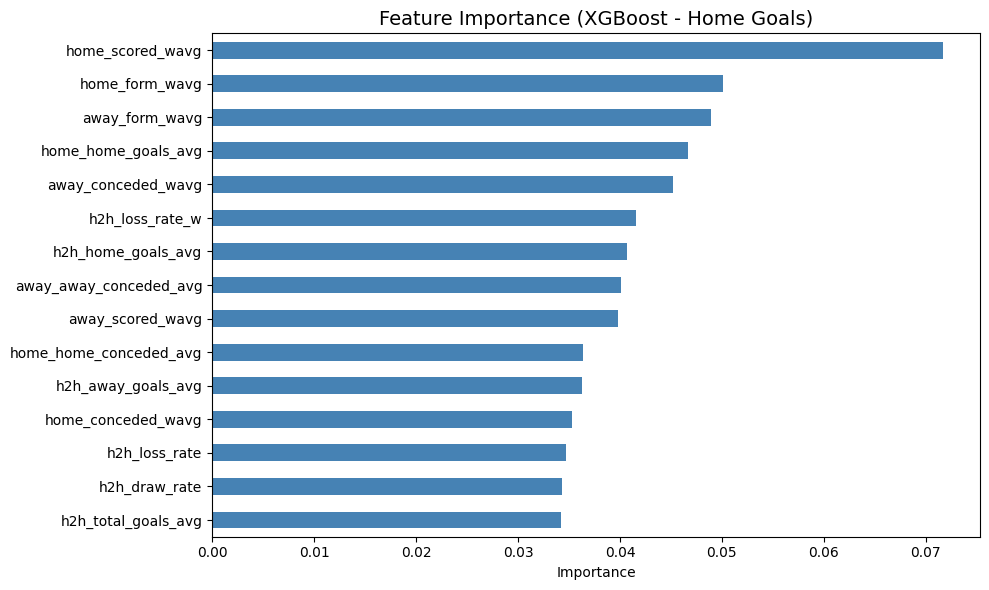

In [ ]:
# Feature importance (XGBoost)
fi = pd.Series(xgb_home.feature_importances_, index=FEATURE_COLS)
fi_sorted = fi.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
fi_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (XGBoost - Home Goals)', fontsize=14)
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Độ chính xác kết quả (W/D/L): 44.7%
Độ chính xác tỉ số chính xác: 9.5%
MAE Home Goals: 0.994
MAE Away Goals: 0.848


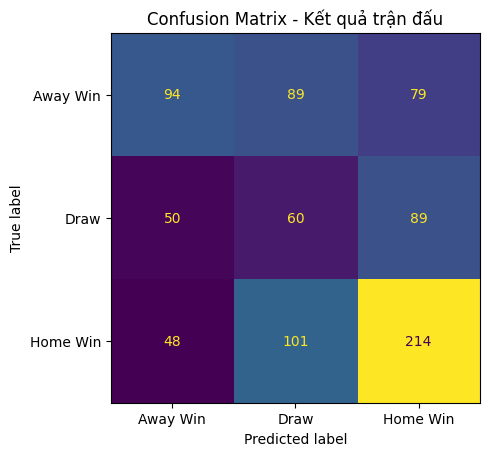

In [ ]:
# Dùng XGBoost để đánh giá chi tiết
ph = xgb_home.predict(X_test)
pa = xgb_away.predict(X_test)

ph_round = np.round(ph).astype(int).clip(0)
pa_round = np.round(pa).astype(int).clip(0)

# Độ chính xác kết quả (thắng/hòa/thua)
true_result = np.sign(yh_test - ya_test)
pred_result = np.sign(ph_round - pa_round)
result_acc  = (true_result == pred_result).mean()

# Độ chính xác tỉ số chính xác
exact_score_acc = ((ph_round == yh_test) & (pa_round == ya_test)).mean()

print(f'Độ chính xác kết quả (W/D/L): {result_acc:.1%}')
print(f'Độ chính xác tỉ số chính xác: {exact_score_acc:.1%}')
print(f'MAE Home Goals: {mean_absolute_error(yh_test, ph_round):.3f}')
print(f'MAE Away Goals: {mean_absolute_error(ya_test, pa_round):.3f}')

# Confusion matrix kết quả
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(true_result, pred_result, labels=[-1, 0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['Away Win', 'Draw', 'Home Win'])
disp.plot(colorbar=False)
plt.title('Confusion Matrix - Kết quả trận đấu')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Xem một số dự đoán mẫu
sample_df = feat_clean.iloc[split:split+20].copy()
sample_df['pred_home'] = ph_round[:20]
sample_df['pred_away'] = pa_round[:20]
sample_df['actual_score'] = sample_df['home_goals'].astype(str) + '-' + sample_df['away_goals'].astype(str)
sample_df['pred_score']   = sample_df['pred_home'].astype(str)  + '-' + sample_df['pred_away'].astype(str)

# Merge lại để hiển thị tên đội
disp_cols = ['match_id', 'actual_score', 'pred_score']
merge_df = sample_df[disp_cols].merge(
    df[['id','home_team_name','away_team_name','league_name','date']],
    left_on='match_id', right_on='id'
)
merge_df['correct'] = merge_df['actual_score'] == merge_df['pred_score']
print(merge_df[['date','home_team_name','away_team_name','league_name','actual_score','pred_score','correct']].to_string(index=False))

      date    home_team_name    away_team_name    league_name actual_score pred_score  correct
2024-03-02           Everton          West Ham Premier League      1.0-3.0        1-1    False
2024-03-02         Tottenham    Crystal Palace Premier League      3.0-1.0        2-1    False
2024-03-02            Fulham          Brighton Premier League      3.0-0.0        2-2    False
2024-03-02         Newcastle            Wolves Premier League      3.0-0.0        2-1    False
2024-03-02         Brentford           Chelsea Premier League      2.0-2.0        2-2    False
2024-03-02 Nottingham Forest         Liverpool Premier League      0.0-1.0        1-2    False
2024-03-03   Manchester City Manchester United Premier League      3.0-1.0        2-1    False
2024-03-09 Manchester United           Everton Premier League      2.0-0.0        1-1    False
2024-03-09           Arsenal         Brentford Premier League      2.0-1.0        3-1    False
2024-03-09            Wolves            Fulham Pre

In [ ]:
def predict_match(home_team_name, away_team_name, league='Premier League',
                  match_date=None, model_home=None, model_away=None,
                  scaler=None, use_poisson_dist=True):
    """
    Dự đoán tỉ số cho một trận đấu mới.

    Params:
        home_team_name: tên đội chủ nhà
        away_team_name: tên đội khách
        league: tên giải
        match_date: ngày thi đấu (mặc định = hôm nay)
        use_poisson_dist: nếu True, dùng phân phối Poisson để tính xác suất
    """
    from scipy.stats import poisson
    if match_date is None:
        match_date = pd.Timestamp.today()

    # Tìm team_id
    home_ids = df[df['home_team_name'].str.lower() == home_team_name.lower()]['home_team_id'].unique()
    away_ids = df[df['away_team_name'].str.lower() == away_team_name.lower()]['away_team_id'].unique()

    if len(home_ids) == 0:
        home_ids = df[df['away_team_name'].str.lower() == home_team_name.lower()]['away_team_id'].unique()
    if len(away_ids) == 0:
        away_ids = df[df['home_team_name'].str.lower() == away_team_name.lower()]['home_team_id'].unique()

    if len(home_ids) == 0 or len(away_ids) == 0:
        print('Không tìm thấy tên đội. Kiểm tra lại.')
        return None

    home_id = int(home_ids[0])
    away_id = int(away_ids[0])

    # Tạo fake row để extract features
    fake_row = pd.DataFrame([{
        'id': 99999, 'home_team_id': home_id, 'home_team_name': home_team_name,
        'away_team_id': away_id, 'away_team_name': away_team_name,
        'league_name': league, 'home_goals': 0, 'away_goals': 0,
        'date': pd.Timestamp(match_date)
    }])
    df_temp = pd.concat([df, fake_row], ignore_index=True)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp = df_temp.sort_values('date').reset_index(drop=True)

    fake_idx = df_temp[df_temp['id'] == 99999].index[0]
    feat = extract_h2h_features(df_temp, fake_idx, n_recent=15)
    feat_vec = np.array([[feat.get(c, np.nan) for c in FEATURE_COLS]])
    feat_vec = imputer.transform(feat_vec)

    if scaler:
        feat_vec = scaler.transform(feat_vec)

    lam_home = float(model_home.predict(feat_vec)[0])
    lam_away = float(model_away.predict(feat_vec)[0])
    lam_home = max(lam_home, 0.1)
    lam_away = max(lam_away, 0.1)

    pred_home = round(lam_home)
    pred_away = round(lam_away)

    print(f'\n🏟  {home_team_name} vs {away_team_name}  [{league}]')
    print(f'📅  {match_date}')
    print(f'⚽  Dự đoán tỉ số: {pred_home} - {pred_away}')
    print(f'   λ home = {lam_home:.2f} | λ away = {lam_away:.2f}')

    if use_poisson_dist:
        max_goals = 8
        prob_matrix = np.outer(
            [poisson.pmf(i, lam_home) for i in range(max_goals)],
            [poisson.pmf(j, lam_away) for j in range(max_goals)]
        )
        p_home_win  = np.tril(prob_matrix, -1).sum()
        p_draw      = np.trace(prob_matrix)
        p_away_win  = np.triu(prob_matrix, 1).sum()

        print(f'\n📊  Xác suất (Poisson):')
        print(f'   Thắng {home_team_name}: {p_home_win:.1%}')
        print(f'   Hòa:                   {p_draw:.1%}')
        print(f'   Thắng {away_team_name}: {p_away_win:.1%}')

        # Visualize ma trận xác suất
        plt.figure(figsize=(8, 6))
        sns.heatmap(prob_matrix * 100, annot=True, fmt='.1f', cmap='YlOrRd',
                    xticklabels=range(max_goals), yticklabels=range(max_goals))
        plt.xlabel(f'Bàn thắng {away_team_name}')
        plt.ylabel(f'Bàn thắng {home_team_name}')
        plt.title(f'Ma trận xác suất tỉ số (%) - {home_team_name} vs {away_team_name}')
        plt.tight_layout()
        plt.savefig('score_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()

    return pred_home, pred_away

print('Hàm predict_match đã sẵn sàng!')

Hàm predict_match đã sẵn sàng!



🏟  Chelsea vs Everton  [Premier League]
📅  2026-05-20
⚽  Dự đoán tỉ số: 2 - 1
   λ home = 1.50 | λ away = 1.10

📊  Xác suất (Poisson):
   Thắng Chelsea: 46.4%
   Hòa:                   25.8%
   Thắng Everton: 27.8%


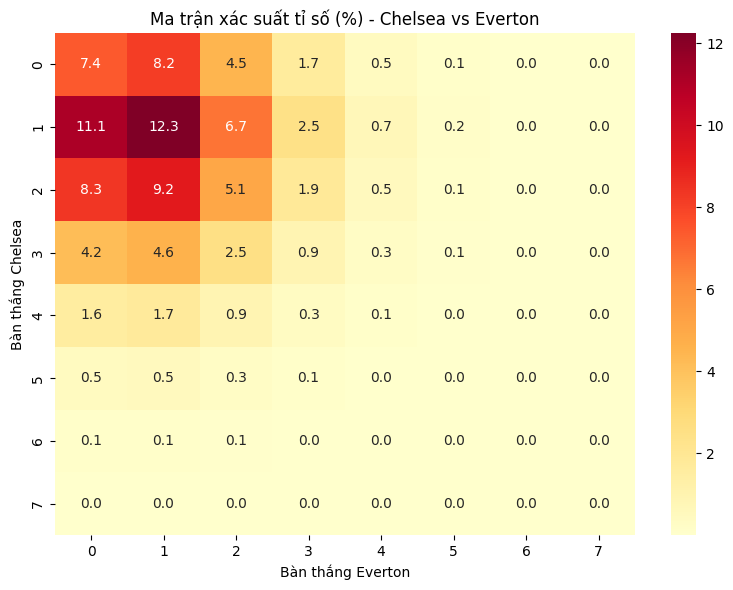

(2, 1)

In [ ]:
# Ví dụ dự đoán
# Thay tên đội bằng các đội có trong dataset của bạn
predict_match(
    home_team_name='Chelsea',
    away_team_name='Everton',
    league='Premier League',
    match_date='2026-05-20',
    model_home=xgb_home,
    model_away=xgb_away,
    use_poisson_dist=True
)


🏟  Liverpool vs Crystal Palace  [Premier League]
📅  2026-05-20
⚽  Dự đoán tỉ số: 2 - 1
   λ home = 1.86 | λ away = 1.39

📊  Xác suất (Poisson):
   Thắng Liverpool: 48.6%
   Hòa:                   22.6%
   Thắng Crystal Palace: 28.8%


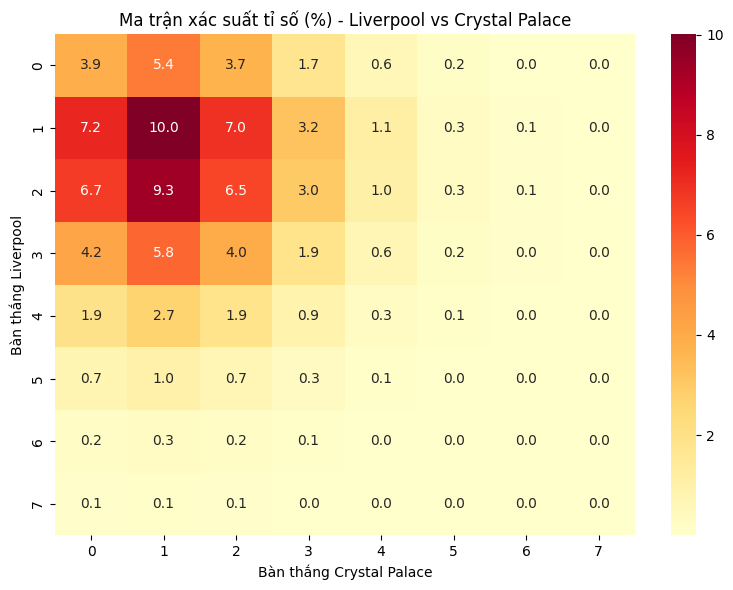

(2, 1)

In [ ]:
# Thử thêm cặp khác
predict_match(
    home_team_name='Liverpool',
    away_team_name='Crystal Palace',
    league='Premier League',
    match_date='2026-05-20',
    model_home=xgb_home,
    model_away=xgb_away,
    use_poisson_dist=True
)

In [ ]:
import joblib

joblib.dump(xgb_home, 'model_home_goals.pkl')
joblib.dump(xgb_away, 'model_away_goals.pkl')
joblib.dump(imputer,  'imputer.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')

print('✅ Đã lưu model!')

# Download về máy
from google.colab import files
for f_name in ['model_home_goals.pkl', 'model_away_goals.pkl', 'imputer.pkl', 'feature_cols.pkl']:
    files.download(f_name)

✅ Đã lưu model!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from scipy.stats import poisson as poisson_dist
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def predict_colab(home_team_name, away_team_name, league='Premier League', match_date=None):
    """
    Dự đoán tỉ số sử dụng Ensemble của 4 model đã train.
    Nếu không nhập match_date, mặc định sẽ lấy ngày hiện tại.
    """
    # Nếu không nhập ngày, lấy ngày hiện tại
    if match_date is None:
        match_date = pd.Timestamp.today()
    else:
        match_date = pd.to_datetime(match_date)

    # ── Tìm team_id ──
    home_ids = df[df['home_team_name'].str.lower() == home_team_name.lower()]['home_team_id'].unique()
    away_ids = df[df['away_team_name'].str.lower() == away_team_name.lower()]['away_team_id'].unique()

    if len(home_ids) == 0 or len(away_ids) == 0:
        print('❌ Không tìm thấy tên đội. Kiểm tra lại.')
        return

    # ── Tạo features ──
    fake = pd.DataFrame([{
        'id': 99999, 'home_team_id': int(home_ids[0]), 'home_team_name': home_team_name,
        'away_team_id': int(away_ids[0]), 'away_team_name': away_team_name,
        'league_name': league, 'home_goals': 0, 'away_goals': 0,
        'date': match_date
    }])
    dt = pd.concat([df, fake], ignore_index=True)
    dt['date'] = pd.to_datetime(dt['date'])
    dt = dt.sort_values('date').reset_index(drop=True)
    fidx = dt[dt['id'] == 99999].index[0]

    feat   = extract_h2h_features(dt, fidx, n_recent=15)
    fv     = np.array([[feat.get(c, np.nan) for c in FEATURE_COLS]])
    fv_imp = imputer.transform(fv)
    fv_sc  = scaler.transform(fv_imp)

    # ── Chạy 4 model đã huấn luyện ──
    models = {
        'XGBoost':      (xgb_home.predict(fv_imp)[0],  xgb_away.predict(fv_imp)[0]),
        'LightGBM':     (lgb_home.predict(fv_imp)[0],  lgb_away.predict(fv_imp)[0]),
        'Poisson':      (poi_home.predict(fv_sc)[0],   poi_away.predict(fv_sc)[0]),
        'RandomForest': (rf_home.predict(fv_imp)[0],   rf_away.predict(fv_imp)[0]),
    }

    def score_matrix(lh, la, mg=8):
        mat  = np.outer([poisson_dist.pmf(i, max(lh,0.1)) for i in range(mg)],
                        [poisson_dist.pmf(j, max(la,0.1)) for j in range(mg)])
        best = np.unravel_index(np.argmax(mat), mat.shape)
        return best[0], best[1], np.tril(mat,-1).sum(), np.trace(mat), np.triu(mat,1).sum(), mat

    print(f'\n🏟  {home_team_name} vs {away_team_name} ({match_date.date()})')
    print(f'{"Model":<14} {"Home λ":>7} {"Away λ":>7} {"Score":>6} {"Home%":>6} {"Draw%":>6} {"Away%":>6}')

    lhs, las, rows = [], [], []
    for name, (lh, la) in models.items():
        lh, la = max(float(lh), 0.1), max(float(la), 0.1)
        ph, pa, p_hw, p_dr, p_aw, mat = score_matrix(lh, la)
        lhs.append(lh); las.append(la)
        rows.append((name, lh, la, ph, pa, p_hw, p_dr, p_aw, mat))
        print(f'{name:<14} {lh:>7.2f} {la:>7.2f} {ph}-{pa:>1} {p_hw:>7.1%} {p_dr:>6.1%} {p_aw:>6.1%}')

    # Ensemble (Trung bình cộng)
    ens_h, ens_a = np.mean(lhs), np.mean(las)
    eph, epa, ep_hw, ep_dr, ep_aw, ens_mat = score_matrix(ens_h, ens_a)
    print('-' * 65)
    print(f'⭐ Ensemble     {ens_h:>7.2f} {ens_a:>7.2f} {eph}-{epa:>1} {ep_hw:>7.1%} {ep_dr:>6.1%} {ep_aw:>6.1%}')

# Gọi hàm không cần ngày (mặc định hôm nay)
predict_colab('Chelsea', 'Everton')
predict_colab('Liverpool', 'Arsenal')


🏟  Chelsea vs Everton (2026-05-21)
Model           Home λ  Away λ  Score  Home%  Draw%  Away%
XGBoost           1.50    1.10 1-1   46.4%  25.8%  27.8%
LightGBM          1.50    1.02 1-1   48.2%  26.0%  25.9%
Poisson           1.50    1.23 1-1   43.5%  25.4%  31.1%
RandomForest      1.51    1.10 1-1   46.6%  25.7%  27.7%
-----------------------------------------------------------------
⭐ Ensemble        1.50    1.11 1-1   46.1%  25.7%  28.1%

🏟  Liverpool vs Arsenal (2026-05-21)
Model           Home λ  Away λ  Score  Home%  Draw%  Away%
XGBoost           1.49    1.48 1-1   37.9%  24.5%  37.6%
LightGBM          1.67    1.69 1-1   38.1%  22.8%  39.0%
Poisson           1.44    1.34 1-1   39.6%  25.3%  35.1%
RandomForest      1.49    1.48 1-1   38.1%  24.4%  37.5%
-----------------------------------------------------------------
⭐ Ensemble        1.52    1.50 1-1   38.4%  24.2%  37.3%
